# Linear Regression Final Model

Existing studies on waste bin fill-level prediction commonly adopt linear or regression-based approaches as an initial benchmark to estimate short-term bin fill behaviour and support collection planning. These studies subsequently apply more advanced models, such as Gaussian Process Regression, which have been shown to achieve better predictive performance (Brouwer et al., 2023; Ferrer & Alba, 2019). However, given the scope and constraints of this project, linear regression was selected as it was able to produce reasonably accurate predictions while remaining simple (Brouwer et al., 2023; Ferrer & Alba, 2019; Krishna et al., 2025).

The final model adopts a revised feature set compared to Draft 2 to better reflect the operational characteristics of e-waste bin collection in our project. Instead of directly predicting the next day fill level, the model is trained to predict the average daily fill growth of the next cycle. This allows downstream estimation of the number of days required for a bin to reach a predefined collection threshold of 80%.

The final feature set used for model training is as follows (using table C):
- ContainerID
- collection_fill_percentage
- cycle_start_month
- cycle_duration_days
- avg_daily_fill_growth

The target variable for the model is:
- Next-cycle average daily fill growth





‌



In [6]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("SA61team5/AD-tableC")

df = pd.DataFrame(dataset["train"])

print(df.shape)


(1863, 10)


In [7]:
df.head()

,Index,ContainerID,Cidx,start_timestamp,end_timestamp,collection_fill_percentage,cycle_start_month,cycle_duration_days,avg_daily_fill_growth,next_cycle_avg_daily_fill_growth
0,0,1,0.0,2021-01-16 11:30:00,2021-02-01 17:10:00,100.0,1,16,6.250000,14.666667
1,1,1,2.0,2021-02-01 20:11:00,2021-02-05 14:43:00,44.0,2,3,14.666667,12.000000
2,2,1,4.0,2021-02-06 01:15:00,2021-02-12 22:09:00,72.0,2,6,12.000000,16.666667
3,3,1,5.0,2021-02-12 23:10:00,2021-02-19 16:34:00,100.0,2,6,16.666667,16.666667
4,4,1,6.0,2021-02-20 12:08:00,2021-02-26 19:02:00,100.0,2,6,16.666667,23.666667


## Time-based train-test split

Instead of randomly splitting the data, earlier records will be used for training while later records are reserved for testing.

In [8]:
df["start_timestamp"] = pd.to_datetime(df["start_timestamp"])
split_date = df["start_timestamp"].quantile(0.75)
print(f"Splitting data at: {split_date}")

train_df = df[df["start_timestamp"] <= split_date]
test_df  = df[df["start_timestamp"] > split_date]
print(f"Training samples: {len(train_df)}, Test samples: {len(test_df)}")

features = [
    "ContainerID",
    "collection_fill_percentage",
    "cycle_start_month",
    "cycle_duration_days",
    "avg_daily_fill_growth"
]

target = "next_cycle_avg_daily_fill_growth"

# Encode Container ID
X_train_raw = train_df[features]
X_test_raw  = test_df[features]

X_train = pd.get_dummies(X_train_raw, columns=["ContainerID"], drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=["ContainerID"], drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

y_train = train_df[target]
y_test  = test_df[target]

Splitting data at: 2023-01-18 16:58:30
Training samples: 1397, Test samples: 466


## Model Training

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Prediction

In [10]:
y_pred = model.predict(X_test)

## Model Evaluation
Mean Absolute Error (MAE) is used to measure the average absolute difference between the predicted and actual bin fill levels, indicating how far predictions typically deviate from actual fill levels. (Ferrer & Alba, 2019; Krishna et al., 2025).

Root Mean Squared Error (RMSE) is used to assess the impact of large errors on planning decisions (Krishna et al., 2025).

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 : {r2:.2f}")

MAE  : 8.10
RMSE : 13.38
R2 : 0.34


## Intepreting Evaluation Results
1) MAE = 8.10

    On average, the model’s predicted average daily fill growth for the next cycle differs from the actual fill level by about 8 percentage points. This level of error is comparable to the MAE of 7.41% reported for a linear regression model in prior e-waste bin fill-level prediction studies (Ferrer & Alba, 2019)

2) RMSE = 13.38

    RMSE indicates that while most predictions deviate from the actual results by about 8 percentage points, there are cases where larger errors occur, with deviations of up to around 13.3 percentage points. These larger errors may occur during irregular fill behaviour, such as sudden increases in usage or or variations related to collection schedules.

## Partial Dependence Plot 
Partial Dependence Plots were used to analyse how each feature influences the predicted next fill level while holding other features constant. 

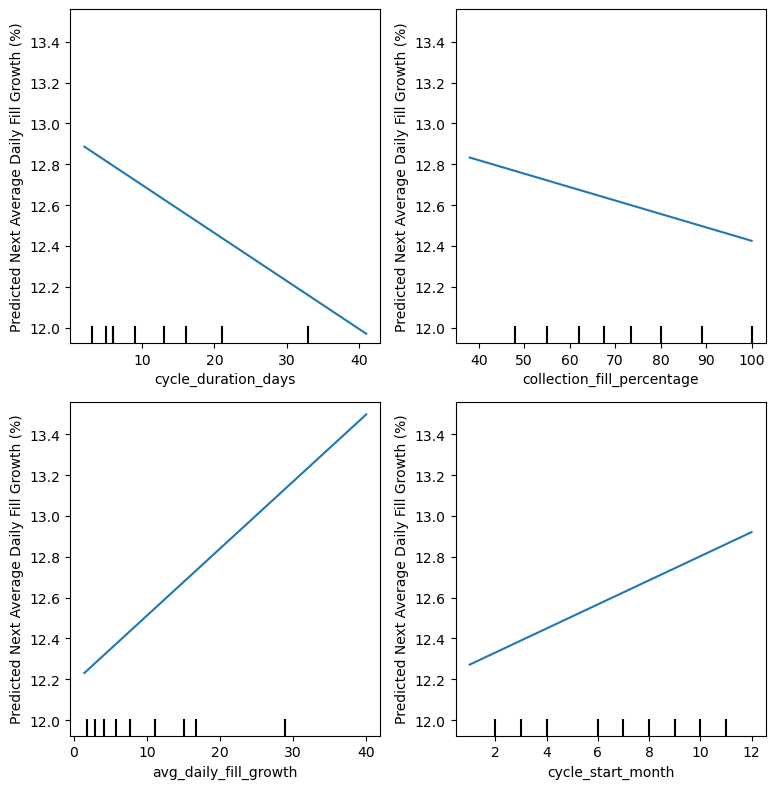

In [7]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import math

pdp_features = [
    "cycle_duration_days",
    "collection_fill_percentage",
    "avg_daily_fill_growth",
    "cycle_start_month"
]

n_features = len(pdp_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(8, 4 * n_rows))
ax = ax.flatten()

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=pdp_features,
    ax=ax[:n_features],
    grid_resolution=60
)

for i in range(n_features):
    ax[i].set_ylabel("Predicted Next Average Daily Fill Growth (%)")
    ax[i].set_xlabel(pdp_features[i])

plt.tight_layout()
plt.show()

Across all four plots, the predicted next-cycle average daily fill growth varies within a relatively narrow range (approximately 12.0% to 13.5%), suggesting that no single feature strongly impacted the prediction.

## Post-Prediction Processing
The predicted growth rate is used to estimate the number of days required for a bin to reach the 80% fill threshold, which serves as the trigger point for collection.

In [8]:
def estimate_days_to_threshold(pred_fill_growth, threshold=80):
    return threshold / pred_fill_growth

def predict_and_calculate(container_id, collection_fill_percentage, cycle_duration_days, cycle_start_month, model, X_train, threshold=80):
    avg_daily_fill_growth = collection_fill_percentage / cycle_duration_days

    X_input = pd.DataFrame([{
        "ContainerID": container_id,
        "collection_fill_percentage": collection_fill_percentage,
        "cycle_start_month": cycle_start_month,
        "cycle_duration_days": cycle_duration_days,
        "avg_daily_fill_growth": avg_daily_fill_growth
    }])

    X_input = pd.get_dummies(X_input, columns=["ContainerID"])
    X_input = X_input.reindex(columns=X_train.columns, fill_value=0)

    pred_fill_growth = model.predict(X_input)[0]

    days_to_threshold = estimate_days_to_threshold(pred_fill_growth, threshold)

    return {
        "predicted_next_avg_daily_growth": float(pred_fill_growth),
        "estimated_days_to_threshold": int(days_to_threshold)
    }


In [9]:
result = predict_and_calculate(
    container_id=1,
    collection_fill_percentage=42,
    cycle_duration_days=10,
    cycle_start_month=5,
    model=model,
    X_train=X_train
)

print(result)

{'predicted_next_avg_daily_growth': 17.256694653214627, 'estimated_days_to_threshold': 4}


## References

Brouwer, Y., Ana Paula Barbosa-Póvoa, António Pais Antunes, & Rodrigues, T. (2023). Comparison of different waste bin monitoring approaches: An exploratory study. Waste Management & Research (Online), 41(10), 1570–1583. https://doi.org/10.1177/0734242x231160691
‌

Ferrer, J., & Alba, E. (2019). BIN-CT: Urban waste collection based on predicting the container fill level. Biosystems, 186, 103962. https://doi.org/10.1016/j.biosystems.2019.04.006

Krishna, S. R., Bhukya Kranthikumar, Swathy Vodithala, Waseem, Md. Sharfuddin., & Kireet Muppavaram. (2025). A Machine Learning Framework For Predictive Waste Management Optimization In Smart Cities. International Journal of Environmental Sciences, 11(12s), 328–334. https://doi.org/10.64252/zp92vp11

# Model Deployment

The final model code has been extracted to `final_LR_Model.py` for easier testing and SonarQube scanning. This notebook calls the Python file to train the model and save it as `.pkl` files for deployment.

In [3]:
# Import the final model from the Python file 
import os
import sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from final_LR_Model import main

# Run the pipeline and save the trained model to the root directory
root_dir = os.path.join(os.getcwd(), "..")
_ = main(save_model=True, output_dir=root_dir)


Starting ML Pipeline
Loading dataset...
Loaded 1863 records
Training model...
Evaluating model...
MAE: 8.10, RMSE: 13.38, R²: 0.3384
Model saved to: /Users/angelineyap/Desktop/ad_project/AD-Project---ML/Notebooks/../model.pkl
Features saved to: /Users/angelineyap/Desktop/ad_project/AD-Project---ML/Notebooks/../feature_columns.pkl
Pipeline completed!
